<a href="https://colab.research.google.com/github/Abdullahali77/Autonomous-Vehicle-Perception-Module/blob/main/phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")


Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.


In [2]:
import os
from tqdm import tqdm
import numpy as np
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [3]:
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

In [4]:
NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [5]:
print("Loading data from folder structure...")

train_paths = []
train_labels = []

# Loop through each class folder (0 to 42)
for class_id in tqdm(range(NUM_CLASSES), desc="Scanning class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if os.path.exists(class_folder):
        # Get all PNG files in the folder
        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)
                train_paths.append(img_path)
                train_labels.append(class_id)

print(f"\nTotal training images found: {len(train_paths):,}")

Loading data from folder structure...


Scanning class folders: 100%|██████████| 43/43 [00:00<00:00, 51.48it/s]


Total training images found: 39,209


In [31]:
#print the shape of the first image to verify loading
if train_paths:
    sample_image = Image.open(train_paths[50])
    print(f"Sample image size: {sample_image.size} (width x height)")

Sample image size: (72, 72) (width x height)


In [7]:
#load images into train data frame
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

In [8]:
class MyImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image lazily (only when needed)
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Split paths and labels (80% train, 20% validation)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, random_state=42
)

# Create Datasets
train_ds = MyImageDataset(train_paths, train_labels, transform=data_transforms)
val_ds = MyImageDataset(val_paths, val_labels, transform=data_transforms)

# Create Loaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # Feature Extraction
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # Classification Head
        # If input 64x64, after two 2x2 pools it becomes 32x32
        self.fc1 = nn.Linear(32 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Feature extraction
        x = self.pool(F.relu(self.conv2(x))) # Feature extraction
        x = x.view(x.size(0), -1)            # Flatten for the NN
        x = F.relu(self.fc1(x))              # Classification
        x = self.fc2(x)
        return x

In [11]:
#use SimpleCNN to train the model
import torch.optim as optim
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_CNN(num_epochs, train_loader, val_loader, model, criterion, optimizer):

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train() # Set to training mode
        train_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass: Get predictions
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass: Optimize the weights
            optimizer.zero_grad() # Clear old gradients
            loss.backward()      # Calculate new gradients
            optimizer.step()     # Update weights

            train_loss += loss.item()

        # --- VALIDATION PHASE ---
        model.eval() # Set to evaluation mode (turns off dropout, etc.)
        val_correct = 0
        val_total = 0

        with torch.no_grad(): # Disable gradient calculation (saves memory/time)
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                # The output is a raw score (logit); pick the highest score
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | Val Acc: {100 * val_correct / val_total:.2f}%")

In [ ]:
train_CNN(num_epochs=10, train_loader=train_loader, val_loader=val_loader, model=model, criterion=criterion, optimizer=optimizer)

Epoch [1/10] | Train Loss: 0.7953 | Val Acc: 91.98%
Epoch [2/10] | Train Loss: 0.1178 | Val Acc: 96.16%
Epoch [3/10] | Train Loss: 0.0639 | Val Acc: 95.58%
Epoch [4/10] | Train Loss: 0.0502 | Val Acc: 97.96%
Epoch [5/10] | Train Loss: 0.0312 | Val Acc: 97.44%
Epoch [6/10] | Train Loss: 0.0254 | Val Acc: 98.57%
Epoch [7/10] | Train Loss: 0.0297 | Val Acc: 97.84%
Epoch [8/10] | Train Loss: 0.0238 | Val Acc: 98.33%
Epoch [9/10] | Train Loss: 0.0241 | Val Acc: 98.60%
Epoch [10/10] | Train Loss: 0.0134 | Val Acc: 98.80%


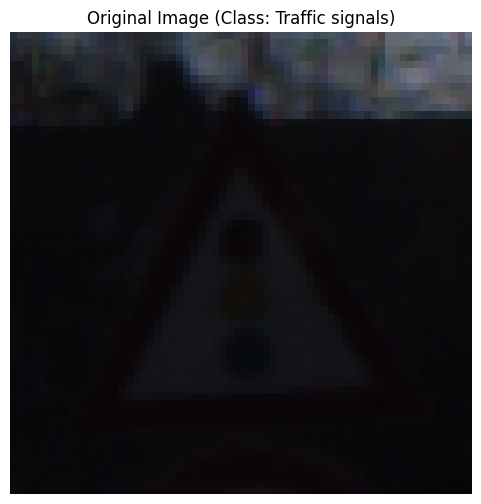

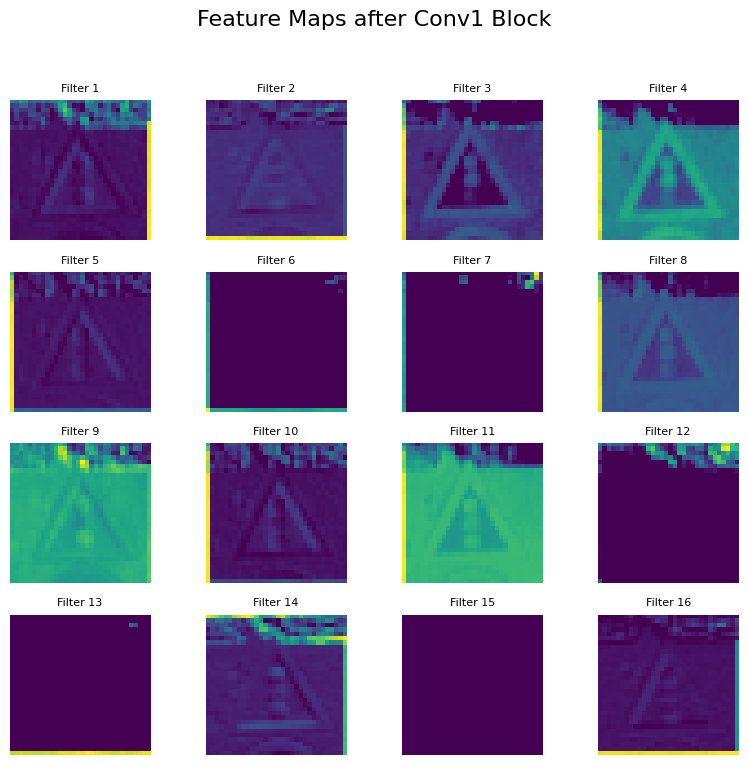

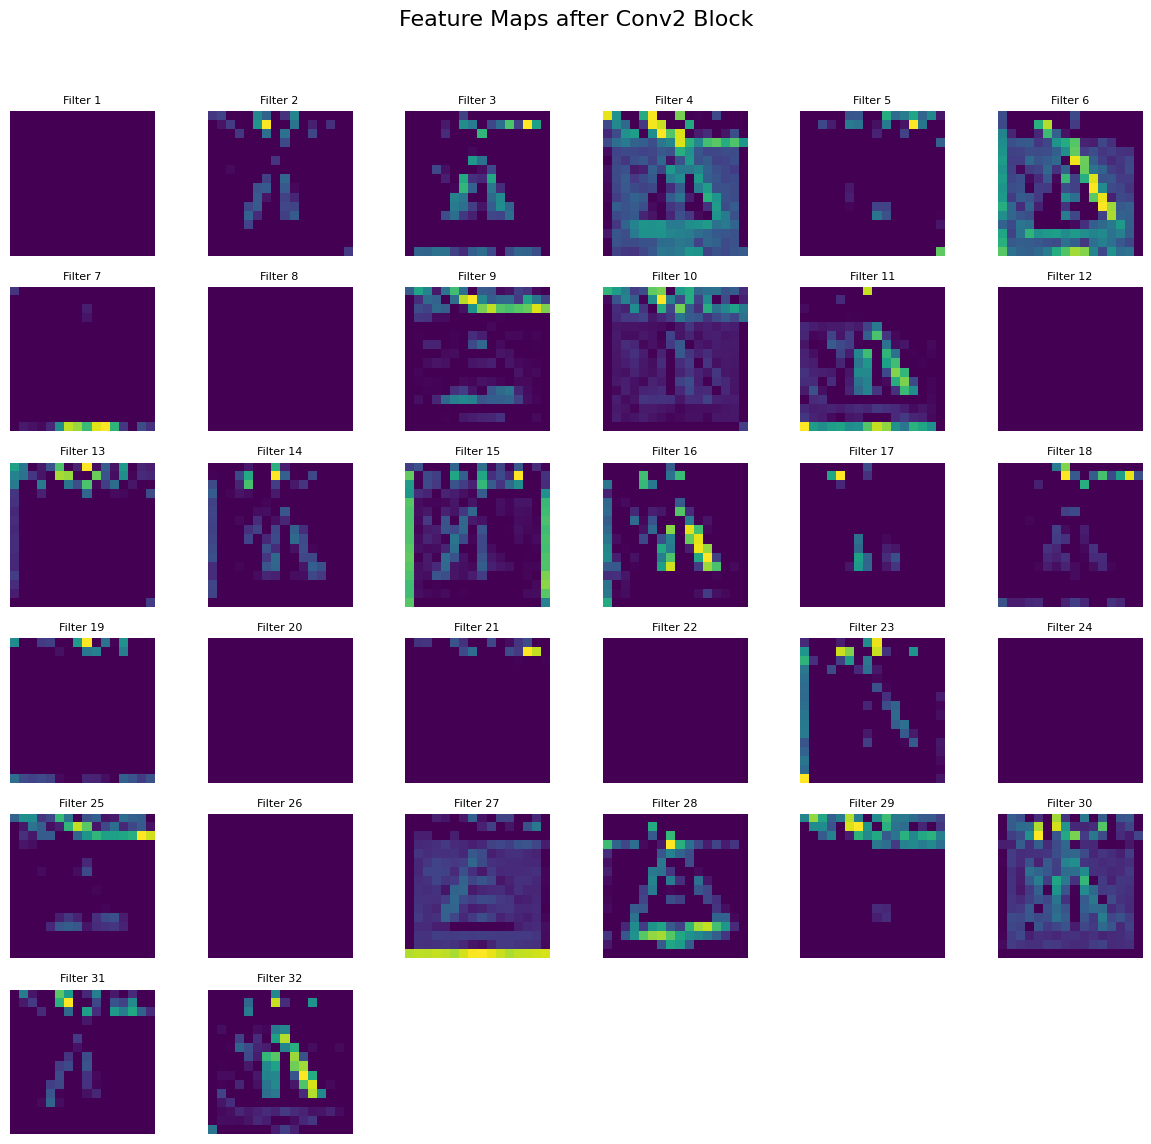

In [ ]:
import matplotlib.pyplot as plt


# Function to unnormalize an image tensor for display
# These mean and std values are the ones used in the data_transforms
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

def unnormalize_image(tensor):
    # tensor: C x H x W
    unnormalized_tensor = tensor.clone()
    for t, m, s in zip(unnormalized_tensor, mean, std):
        t.mul_(s).add_(m)
    return unnormalized_tensor

# Get a sample image from the validation set
# We need to iterate through val_loader to get a batch
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Select the first image from the batch
sample_image_tensor = images[0].unsqueeze(0).to(device) # Add batch dimension (1, C, H, W)
original_image_for_display = unnormalize_image(images[0].cpu()) # Unnormalize for plotting

# Display the original image
plt.figure(figsize=(6, 6))
plt.imshow(original_image_for_display.permute(1, 2, 0).numpy()) # Change to HWC format and convert to numpy
plt.title(f"Original Image (Class: {CLASS_NAMES[labels[0].item()]})")
plt.axis('off')
plt.show()

# Define a temporary model to extract features from intermediate layers
class FeatureExtractionCNN(nn.Module):
    def __init__(self, original_model):
        super(FeatureExtractionCNN, self).__init__()
        # Copy the feature extraction layers from the original model
        self.conv1 = original_model.conv1
        self.pool = original_model.pool
        self.conv2 = original_model.conv2

    def forward(self, x):
        # Pass through the first conv layer, ReLU, and pooling
        features_conv1_pooled = self.pool(F.relu(self.conv1(x)))
        # Pass through the second conv layer, ReLU, and pooling
        features_conv2_pooled = self.pool(F.relu(self.conv2(features_conv1_pooled)))
        return features_conv1_pooled, features_conv2_pooled

# Instantiate the feature extractor and move to device
feature_extractor = FeatureExtractionCNN(model).to(device)
feature_extractor.eval() # Set to evaluation mode

# feature maps
with torch.no_grad():
    features1_output, features2_output = feature_extractor(sample_image_tensor)

# Convert to numpy
features1_np = features1_output.squeeze(0).cpu().numpy() # Shape: (16, H, W)
features2_np = features2_output.squeeze(0).cpu().numpy() # Shape: (32, H, W)

# Helper function
def plot_feature_maps(features_np, title):
    num_filters = features_np.shape[0]
    # Calculate grid dimensions: try to make it roughly square
    grid_size = int(np.ceil(np.sqrt(num_filters)))

    plt.figure(figsize=(grid_size * 2, grid_size * 2)) # Adjust figure size dynamically
    for i in range(num_filters):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(features_np[i], cmap='viridis') # 'viridis' is a good choice for heatmaps
        plt.title(f'Filter {i+1}', fontsize=8)
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    plt.show()

# 1st conv
plot_feature_maps(features1_np, 'Feature Maps after Conv1 Block')

# 2nd conv
plot_feature_maps(features2_np, 'Feature Maps after Conv2 Block')

In [29]:
NOISE_FACTOR = 0.1
NUM_EPOCHS = 30
LR = 0.0005

In [17]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )


        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [18]:
denoise_model = DenoisingAutoencoder().to(device)

criterion = nn.L1Loss()
optimizer = optim.Adam(denoise_model.parameters(), lr=LR)

In [19]:
def train(model, train_loader, val_loader):
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0

        for images, _ in train_loader:
            images = images.to(device)

            noisy = images + NOISE_FACTOR * torch.randn_like(images)
            noisy = torch.clamp(noisy, 0., 1.)

            outputs = model(noisy)
            loss = criterion(outputs, images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, _ in val_loader:
                images = images.to(device)

                noisy = images + NOISE_FACTOR * torch.randn_like(images)
                noisy = torch.clamp(noisy, 0., 1.)

                outputs = model(noisy)
                loss = criterion(outputs, images)

                val_loss += loss.item()

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
              f"Train: {train_loss/len(train_loader):.4f} | "
              f"Val: {val_loss/len(val_loader):.4f}")

In [21]:
print("Training started...")
train(denoise_model, train_loader, val_loader)

Training started...


KeyboardInterrupt: 

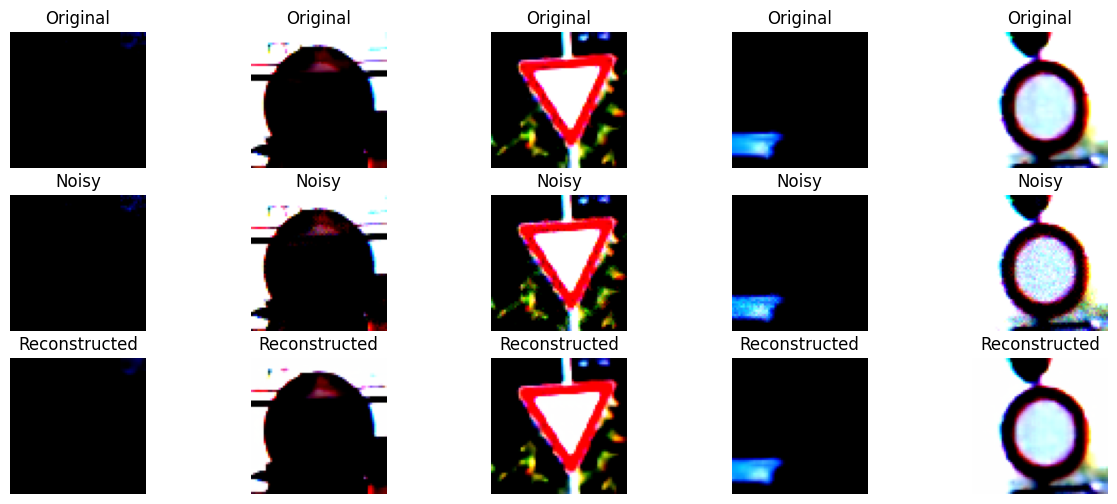

In [30]:
denoise_model.eval()

images, _ = next(iter(val_loader))
images = images.to(device)

noisy = images + NOISE_FACTOR * torch.randn_like(images)
noisy = torch.clamp(noisy, 0., 1.)

with torch.no_grad():
    reconstructed = denoise_model(noisy)

num_samples = 5
plt.figure(figsize=(15, 6))

for i in range(num_samples):

    plt.subplot(3, num_samples, i+1)
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3, num_samples, i+1+num_samples)
    plt.imshow(noisy[i].cpu().permute(1,2,0))
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, num_samples, i+1+2*num_samples)
    plt.imshow(reconstructed[i].cpu().permute(1,2,0))
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()